In [3]:
import polars as pl
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ==============================================================================
print("Загрузка данных...")
# Предполагаем, что файл features.parquet уже сохранен после пайплайна
try:
    df = pl.read_parquet("D:\\Projects\\Coding\\ML\\SamsungML\\data\\JobData\\processed\\features.parquet")
    print(f"Загружено строк: {df.height:,}")
except FileNotFoundError:
    print("Файл features.parquet не найден. Убедитесь, что пайплайн завершен.")

# Конвертация в pandas для sklearn/catboost (опционально, CatBoost поддерживает polars, но pandas надежнее для CV)
data = df.to_pandas()

Загрузка данных...
Загружено строк: 9,914


In [5]:
data.head()

,codeProfessionalSphere,regionName,year,month,vacancy_count,median_salary,median_salary_lag_1,median_salary_lag_2,median_salary_roll_mean_2,median_salary_roll_std_2,target_median_salary,avg_experience,share_remote,share_high_education,share_accommodation,share_small_company,federalDistrictCode,month_sin,month_cos
0,AccountingTaxesManagement,Алтайский край,2026,1,21,35500.0,45000.0,45000.0,40250.0,6717.514648,44500.0,2.095238,0.000000,0.333333,0.000000,0.809524,6,5.000000e-01,0.866025
1,AccountingTaxesManagement,Алтайский край,2026,2,39,44500.0,35500.0,45000.0,40000.0,6363.960938,41000.0,1.205128,0.025641,0.333333,0.025641,0.846154,6,8.660254e-01,0.500000
2,AccountingTaxesManagement,Амурская область,2025,10,4,54250.0,61500.0,57100.0,57875.0,5126.523926,60000.0,2.000000,0.000000,0.500000,0.000000,0.750000,7,-8.660254e-01,0.500000
3,AccountingTaxesManagement,Амурская область,2025,12,7,60000.0,54250.0,61500.0,57125.0,4065.864014,67500.0,2.000000,0.000000,0.714286,0.000000,1.000000,7,-2.449294e-16,1.000000
4,AccountingTaxesManagement,Амурская область,2026,1,13,67500.0,60000.0,54250.0,63750.0,5303.300781,52500.0,1.076923,0.000000,0.769231,0.000000,0.615385,7,5.000000e-01,0.866025


In [6]:
# ==============================================================================
# 2. ПОДГОТОВКА ПРИЗНАКОВ
# ==============================================================================
# Определяем целевую переменную и признаки
target_col = 'target_median_salary'
exclude_cols = [target_col, 'year', 'month'] # Год и месяц лучше закодировать или убрать, если есть sin/cos

# Категориальные признаки для CatBoost
cat_features = ['codeProfessionalSphere', 'regionName']

# Числовые признаки
feature_cols = [col for col in data.columns if col not in exclude_cols and col not in cat_features]

print(f"Числовые признаки: {feature_cols}")

X = data[feature_cols + cat_features]
y = data[target_col]

# Проверка на пропуски (CatBoost умеет, но лучше знать)
print(f"Пропуски в признаках: {X.isnull().sum().sum()}")
print(f"Пропуски в таргете: {y.isnull().sum()}")

# Удаляем строки с пропусками в таргете
mask = y.notnull()
X = X[mask]
y = y[mask]

print(f"Обучающая выборка после очистки: {X.shape[0]} строк, {X.shape[1]} признаков")

Числовые признаки: ['vacancy_count', 'median_salary', 'median_salary_lag_1', 'median_salary_lag_2', 'median_salary_roll_mean_2', 'median_salary_roll_std_2', 'avg_experience', 'share_remote', 'share_high_education', 'share_accommodation', 'share_small_company', 'federalDistrictCode', 'month_sin', 'month_cos']
Пропуски в признаках: 0
Пропуски в таргете: 0
Обучающая выборка после очистки: 9914 строк, 16 признаков


In [7]:
# ==============================================================================
# 3. НАИВНЫЙ БЕЙЗЛАЙН (Naive Benchmark)
# ==============================================================================
# Прогноз: Зарплата следующего месяца = Зарплата текущего месяца (median_salary)
# Это минимальная планка, которую должна побить модель
if 'median_salary' in data.columns:
    y_pred_naive = data.loc[mask, 'median_salary']
    mape_naive = mean_absolute_percentage_error(y, y_pred_naive) * 100
    rmse_naive = root_mean_squared_error(y, y_pred_naive)
    print(f"--- НАИВНЫЙ БЕЙЗЛАЙН ---")
    print(f"MAPE: {mape_naive:.2f}%")
    print(f"RMSE: {rmse_naive:.2f} руб.")
else:
    mape_naive = None
    print("Колонка median_salary не найдена, пропускаем наивный бейзлайн.")

--- НАИВНЫЙ БЕЙЗЛАЙН ---
MAPE: 22.40%
RMSE: 21659.10 руб.


In [8]:
# ==============================================================================
# 4. ОБУЧЕНИЕ МОДЕЛИ (CatBoost)
# ==============================================================================

params = {
    'iterations': 200,
    'depth': 4,
    'learning_rate': 0.05,
    'l2_leaf_reg': 25.0, 
    'loss_function': 'RMSE',
    'eval_metric': 'MAPE',
    'verbose': 50,
    'random_seed': 42,
    'cat_features': cat_features
}

model = CatBoostRegressor(**params)

In [9]:
# ==============================================================================
# 5. TIME SERIES CROSS-VALIDATION
# ==============================================================================
# Используем расширяющееся окно (Expanding Window), так как данные временные
tscv = TimeSeriesSplit(n_splits=3)

cv_scores_mape = []
cv_scores_rmse = []

# Для CV нам нужно сохранить порядок данных! 
# Убедитесь, что data отсортирована по времени перед этим шагом
data = data.sort_values(['year', 'month']) 

print("Запуск кросс-валидации...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    print(f"\nFold {fold + 1}/{tscv.n_splits}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Обучение
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        use_best_model=True
    )
    
    # Предсказание
    y_pred = model.predict(X_val)
    
    # Метрики
    mape = mean_absolute_percentage_error(y_val, y_pred) * 100
    rmse = root_mean_squared_error(y_val, y_pred)
    
    cv_scores_mape.append(mape)
    cv_scores_rmse.append(rmse)
    
    print(f"Fold MAPE: {mape:.2f}% | RMSE: {rmse:.2f}")

Запуск кросс-валидации...

Fold 1/3
0:	learn: 0.2862004	test: 0.2525176	best: 0.2525176 (0)	total: 197ms	remaining: 39.2s
50:	learn: 0.1721646	test: 0.1656090	best: 0.1656090 (50)	total: 2.32s	remaining: 6.78s
100:	learn: 0.1626618	test: 0.1579901	best: 0.1579901 (100)	total: 3.91s	remaining: 3.83s
150:	learn: 0.1594564	test: 0.1573014	best: 0.1563735 (131)	total: 5.21s	remaining: 1.69s
199:	learn: 0.1586238	test: 0.1584454	best: 0.1563735 (131)	total: 6.92s	remaining: 0us

bestTest = 0.1563734879
bestIteration = 131

Shrink model to first 132 iterations.
Fold MAPE: 15.64% | RMSE: 12394.55

Fold 2/3
0:	learn: 0.2722387	test: 0.2679332	best: 0.2679332 (0)	total: 39.8ms	remaining: 7.92s
50:	learn: 0.1663656	test: 0.2019865	best: 0.2019865 (50)	total: 2.12s	remaining: 6.19s
100:	learn: 0.1566577	test: 0.1982352	best: 0.1981314 (94)	total: 4.25s	remaining: 4.16s
150:	learn: 0.1544184	test: 0.1990708	best: 0.1975767 (125)	total: 6.34s	remaining: 2.06s
199:	learn: 0.1533900	test: 0.2017172	b

In [10]:
# ==============================================================================
# 6. ИТОГОВЫЕ РЕЗУЛЬТАТЫ
# ==============================================================================
mean_mape = np.mean(cv_scores_mape)
std_mape = np.std(cv_scores_mape)
mean_rmse = np.mean(cv_scores_rmse)

print("\n" + "="*50)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ (CV)")
print("="*50)
print(f"CatBoost MAPE: {mean_mape:.2f}% (+/- {std_mape:.2f}%)")
print(f"CatBoost RMSE: {mean_rmse:.2f} руб.")

if mape_naive:
    print(f"\nНаивный бейзлайн MAPE: {mape_naive:.2f}%")
    if mean_mape < mape_naive:
        print("✅ Модель ЛУЧШЕ наивного прогноза!")
    else:
        print("❌ Модель ХУЖЕ наивного прогноза. Нужно упрощать признаки или менять агрегацию.")

# ==============================================================================
# 7. ВАЖНОСТЬ ПРИЗНАКОВ
# ==============================================================================
print("\n--- ТОП-10 ВАЖНЫХ ПРИЗНАКОВ ---")
feature_importance = model.get_feature_importance()
fi_df = pd.DataFrame({
    'feature': feature_cols + cat_features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(fi_df.head(10).to_string(index=False))

# Сохранение модели
model.save_model("catboost_salary_model.cbm")
print("\nМодель сохранена в catboost_salary_model.cbm")


ИТОГОВЫЕ РЕЗУЛЬТАТЫ (CV)
CatBoost MAPE: 18.24% (+/- 1.85%)
CatBoost RMSE: 16926.40 руб.

Наивный бейзлайн MAPE: 22.40%
✅ Модель ЛУЧШЕ наивного прогноза!

--- ТОП-10 ВАЖНЫХ ПРИЗНАКОВ ---
                  feature  importance
median_salary_roll_mean_2   38.236067
               regionName   18.188444
      median_salary_lag_2   15.258445
   codeProfessionalSphere   11.242146
            median_salary    9.453965
                month_cos    4.120231
      median_salary_lag_1    2.062460
      federalDistrictCode    0.475341
      share_small_company    0.303482
      share_accommodation    0.259876

Модель сохранена в catboost_salary_model.cbm


Подготовка данных для демонстрации прогноза...
Генерация прогноза для 4 групп...

РЕЗУЛЬТАТЫ ПРОГНОЗИРОВАНИЯ (ПРИМЕР ДЛЯ ПРЕЗЕНТАЦИИ)
           Сфера                        Регион Период прогноза  Прогноз модели  Фактическое значение  Наивный прогноз  Ошибка модели (%)  Ошибка наивного (%)
NotQualification            Московская область         2026-02         50910.0               59000.0          31554.0               13.7            46.500000
       Education             Псковская область         2026-02         36142.0               28546.0          28546.0               26.6             0.000000
        Industry           Ярославская область         2026-02         43916.0               45500.0          30000.0                3.5            34.099998
        Medicine Луганская Народная Республика         2026-02         44165.0               29023.0          31046.0               52.2             7.000000
Результаты сохранены в файл prediction_demo_results.csv


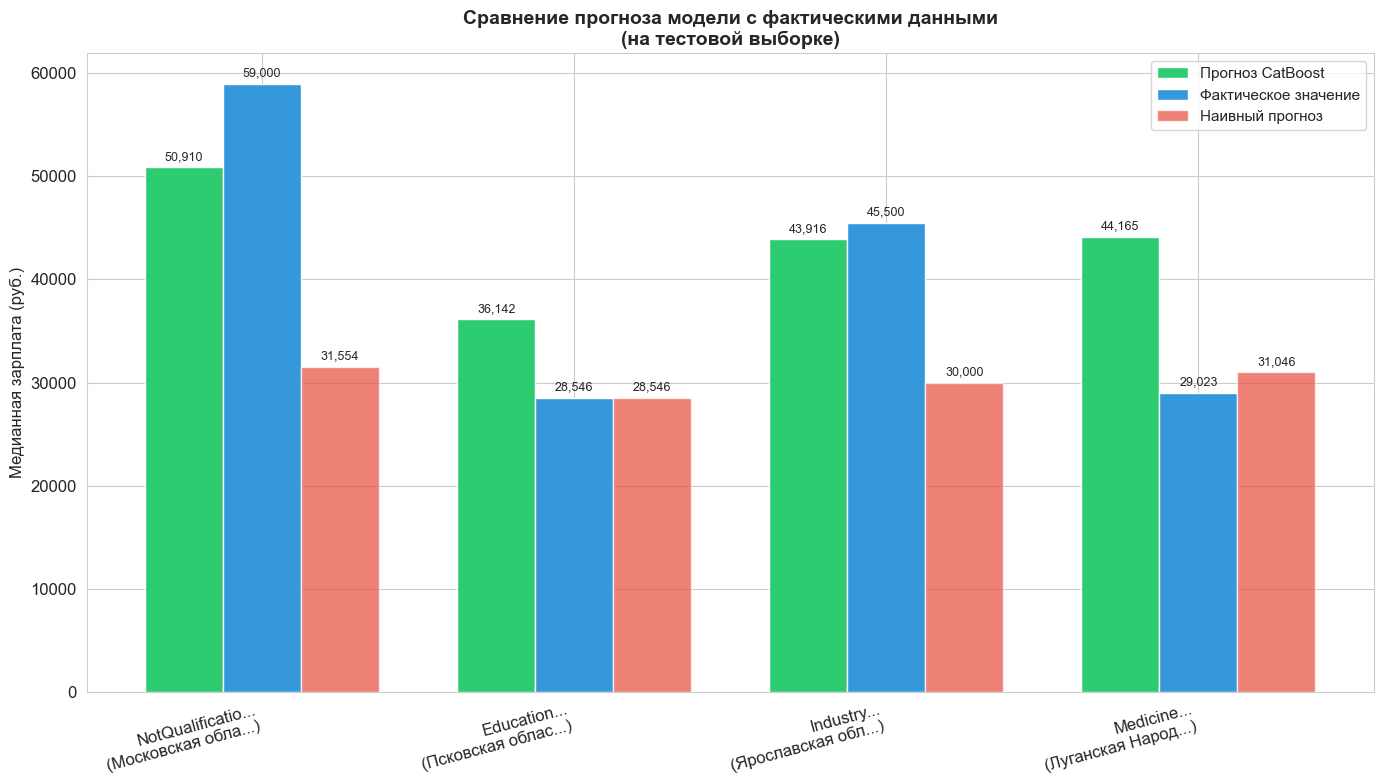

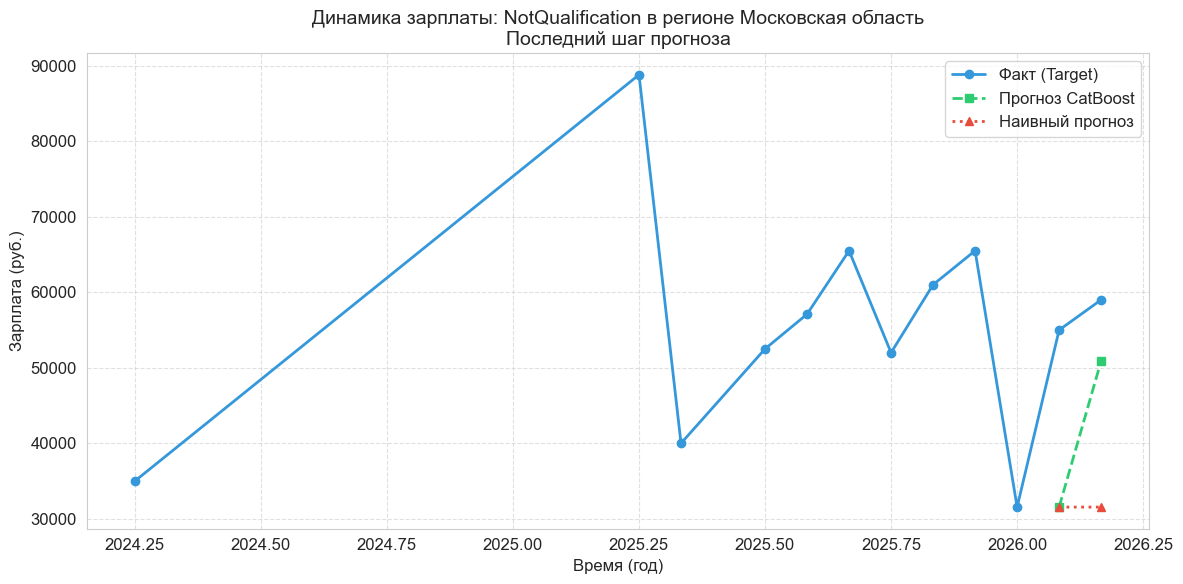

In [14]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройка стилей для красивых графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# ==============================================================================
# 1. ПОДГОТОВКА ДАННЫХ ДЛЯ ПРОГНОЗА
# ==============================================================================
print("Подготовка данных для демонстрации прогноза...")

# Используем тот же датасет, на котором обучали
# Убедитесь, что переменная data существует (из предыдущих ячеек)
if 'data' not in globals():
    df_temp = pl.read_parquet("D:\\Projects\\Coding\\ML\\SamsungML\\data\\JobData\\processed\\features_final.parquet")
    data = df_temp.to_pandas()

# Сортируем по времени, чтобы взять самые последние данные
data = data.sort_values(['year', 'month'])

# Выбираем уникальные комбинации сфер и регионов
unique_groups = data[['codeProfessionalSphere', 'regionName']].drop_duplicates()

# Для презентации выберем 3-4 случайные группы, чтобы не загромождать график
# Или можно выбрать конкретные, например, IT в Москве
demo_groups = unique_groups.sample(n=4, random_state=42) 

# Если хотите конкретные примеры, раскомментируйте строки ниже:
# demo_groups = pd.DataFrame({
#     'codeProfessionalSphere': ['InformationTechnology', 'Medicine'],
#     'regionName': ['Город Москва', 'Город Санкт-Петербург']
# })

# =============================================================================
# ПРОГНОЗ ДЛЯ ПРЕЗЕНТАЦИИ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# =============================================================================

results_list = []

print(f"Генерация прогноза для {len(demo_groups)} групп...")

for idx, row in demo_groups.iterrows():
    sphere = row['codeProfessionalSphere']
    region = row['regionName']
    
    # Берем историю по этой группе
    mask = (data['codeProfessionalSphere'] == sphere) & (data['regionName'] == region)
    group_data = data[mask].copy()
    
    if len(group_data) < 2:
        continue
    
    # Берем предпоследний месяц как "текущий", последний как "факт"
    prev_row = group_data.iloc[-2]
    actual_row = group_data.iloc[-1]
    
    X_input = prev_row[feature_cols_model].to_frame().T
    
    # ВАЖНО: Создаем Pool с указанием категориальных признаков
    pred_pool = Pool(
        data=X_input,
        cat_features=['codeProfessionalSphere', 'regionName']
    )
    
    # Делаем прогноз
    prediction = model.predict(pred_pool)[0]
    actual = actual_row['target_median_salary']
    naive_pred = prev_row['median_salary']
    
    results_list.append({
        'Сфера': sphere,
        'Регион': region,
        'Период прогноза': f"{actual_row['year']}-{int(actual_row['month']):02d}",
        'Прогноз модели': round(prediction, 0),
        'Фактическое значение': round(actual, 0),
        'Наивный прогноз': round(naive_pred, 0),
        'Ошибка модели (%)': round(abs(prediction - actual) / actual * 100, 1),
        'Ошибка наивного (%)': round(abs(naive_pred - actual) / actual * 100, 1)
    })

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results_list)

# ==============================================================================
# 2. ВЫВОД ТАБЛИЦЫ ДЛЯ ПРЕЗЕНТАЦИИ
# ==============================================================================
print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ПРОГНОЗИРОВАНИЯ (ПРИМЕР ДЛЯ ПРЕЗЕНТАЦИИ)")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Сохраним в CSV, если нужно вставить в Excel/PowerPoint
results_df.to_csv("prediction_demo_results.csv", index=False, sep=';', encoding='utf-8-sig')
print("Результаты сохранены в файл prediction_demo_results.csv")

# ==============================================================================
# 3. ВИЗУАЛИЗАЦИЯ
# ==============================================================================
if len(results_df) > 0:
    fig, ax = plt.subplots()
    
    # Данные для графика
    x_labels = [f"{r['Сфера'][:15]}...\n({r['Регион'][:15]}...)" for _, r in results_df.iterrows()]
    model_preds = results_df['Прогноз модели']
    actuals = results_df['Фактическое значение']
    naive_preds = results_df['Наивный прогноз']
    
    x = np.arange(len(x_labels))
    width = 0.25
    
    rects1 = ax.bar(x - width, model_preds, width, label='Прогноз CatBoost', color='#2ecc71')
    rects2 = ax.bar(x, actuals, width, label='Фактическое значение', color='#3498db')
    rects3 = ax.bar(x + width, naive_preds, width, label='Наивный прогноз', color='#e74c3c', alpha=0.7)
    
    ax.set_ylabel('Медианная зарплата (руб.)', fontsize=12)
    ax.set_title('Сравнение прогноза модели с фактическими данными\n(на тестовой выборке)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=15, ha='right')
    ax.legend(fontsize=11)
    
    # Добавим подписи значений на столбцы
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{int(height):,}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
    
    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)
    
    plt.tight_layout()
    plt.show()
    
    # График динамики для одной случайной группы (для красоты слайда)
    if len(results_df) > 0:
        sample_idx = 0
        sphere = results_df.iloc[sample_idx]['Сфера']
        region = results_df.iloc[sample_idx]['Регион']
        
        mask = (data['codeProfessionalSphere'] == sphere) & (data['regionName'] == region)
        hist_data = data[mask].tail(12) # Последние 12 месяцев
        
        plt.figure(figsize=(12, 6))
        plt.plot(hist_data['year'] + hist_data['month']/12, hist_data['target_median_salary'], marker='o', label='Факт (Target)', linewidth=2, color='#3498db')
        
        # Сформируем прогноз для истории (скользящий прогноз)
        # Это упрощенная визуализация: просто покажем, как модель предсказала последний шаг
        last_actual = hist_data.iloc[-1]['target_median_salary']
        last_pred = results_df.iloc[sample_idx]['Прогноз модели']
        last_naive = results_df.iloc[sample_idx]['Наивный прогноз']
        
        # Точка прогноза
        last_time = hist_data.iloc[-1]['year'] + hist_data.iloc[-1]['month']/12
        # Предыдущая точка
        prev_time = hist_data.iloc[-2]['year'] + hist_data.iloc[-2]['month']/12
        
        # Рисуем линию прогноза от предпоследней точки к последней (прогнозируемой)
        plt.plot([prev_time, last_time], [hist_data.iloc[-2]['median_salary'], last_pred], '--', marker='s', label='Прогноз CatBoost', linewidth=2, color='#2ecc71')
        plt.plot([prev_time, last_time], [hist_data.iloc[-2]['median_salary'], last_naive], ':', marker='^', label='Наивный прогноз', linewidth=2, color='#e74c3c')
        
        plt.title(f'Динамика зарплаты: {sphere} в регионе {region}\nПоследний шаг прогноза', fontsize=14)
        plt.xlabel('Время (год)')
        plt.ylabel('Зарплата (руб.)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

else:
    print("Не удалось сформировать примеры для прогноза. Проверьте данные.")